In [ ]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
import math
from smalldiffusion import Swissroll
import numpy as np
import matplotlib.pyplot as plt

c:\Users\dzluk\Syrinx\audio-diffusion-course\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## MNIST

This UNet predicts the denoised image, without taking into account the timestep

In [ ]:

import torchvision

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

def corrupt(x, amount):
  """Corrupt the input `x` by mixing it with noise according to `amount`"""
  noise = torch.rand_like(x)
  amount = amount.view(-1, 1, 1, 1) # Sort shape so broadcasting works
  return x*(1-amount) + noise*amount


class BasicUNet(nn.Module):
    """A minimal UNet implementation."""
    def __init__(self, in_channels=1, out_channels=1):
        super().__init__()
        self.down_layers = torch.nn.ModuleList([ 
            nn.Conv2d(in_channels, 32, kernel_size=5, padding=2),
            nn.Conv2d(32, 64, kernel_size=5, padding=2),
            nn.Conv2d(64, 64, kernel_size=5, padding=2),
        ])
        self.up_layers = torch.nn.ModuleList([
            nn.Conv2d(64, 64, kernel_size=5, padding=2),
            nn.Conv2d(64, 32, kernel_size=5, padding=2),
            nn.Conv2d(32, out_channels, kernel_size=5, padding=2), 
        ])
        self.act = nn.SiLU() # The activation function
        self.downscale = nn.MaxPool2d(2)
        self.upscale = nn.Upsample(scale_factor=2)

    def forward(self, x):
        h = []
        for i, l in enumerate(self.down_layers):
            x = self.act(l(x)) # Through the layer and the activation function
            if i < 2: # For all but the third (final) down layer:
              h.append(x) # Storing output for skip connection
              x = self.downscale(x) # Downscale ready for the next layer
              
        for i, l in enumerate(self.up_layers):
            if i > 0: # For all except the first up layer
              x = self.upscale(x) # Upscale
              x += h.pop() # Fetching stored output (skip connection)
            x = self.act(l(x)) # Through the layer and the activation function
            
        return x

Finished epoch 0. Average loss for this epoch: 0.027018
Finished epoch 1. Average loss for this epoch: 0.020870
Finished epoch 2. Average loss for this epoch: 0.018765


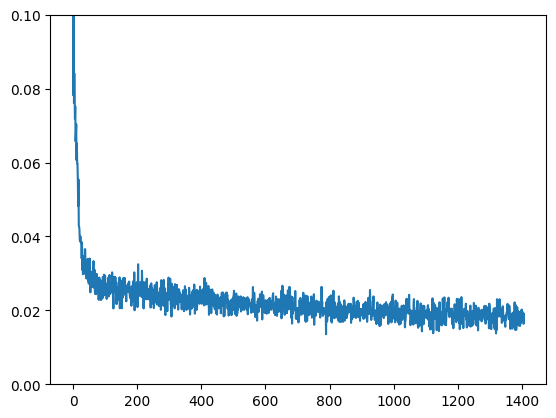

In [ ]:
# Dataloader (you can mess with batch size)
batch_size = 128
dataset = torchvision.datasets.MNIST(root="mnist/", train=True, download=True, transform=torchvision.transforms.ToTensor())
train_dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=True)

# How many runs through the data should we do?
n_epochs = 3

# Create the network
net = BasicUNet()
net.to(device)

# Our loss function
loss_fn = nn.MSELoss()

# The optimizer
opt = torch.optim.Adam(net.parameters(), lr=1e-3) 

# Keeping a record of the losses for later viewing
losses = []

# The training loop
for epoch in range(n_epochs):

    for x, y in train_dataloader:

        # Get some data and prepare the corrupted version
        x = x.to(device) # Data on the GPU
        noise_amount = torch.rand(x.shape[0]).to(device) # Pick random noise amounts
        noisy_x = corrupt(x, noise_amount) # Create our noisy x

        # Get the model prediction
        pred = net(noisy_x)

        # Calculate the loss
        loss = loss_fn(pred, x) # How close is the output to the true 'clean' x?

        # Backprop and update the params:
        opt.zero_grad()
        loss.backward()
        opt.step()

        # Store the loss for later
        losses.append(loss.item())

    # Print our the average of the loss values for this epoch:
    avg_loss = sum(losses[-len(train_dataloader):])/len(train_dataloader)
    print(f'Finished epoch {epoch}. Average loss for this epoch: {avg_loss:05f}')

# View the loss curve
plt.plot(losses)
plt.ylim(0, 0.1)

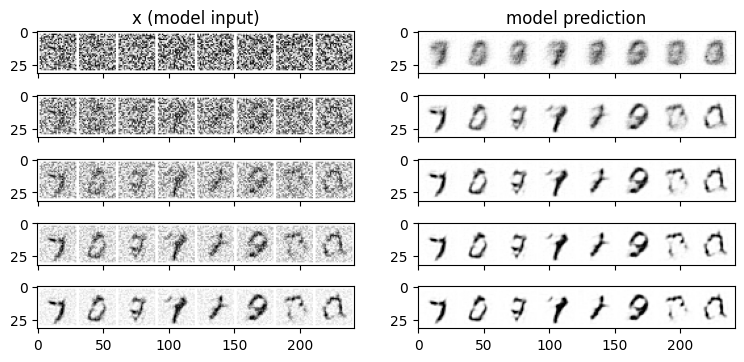

In [ ]:
#@markdown Sampling strategy: Break the process into 5 steps and move 1/5'th of the way there each time:
n_steps = 5
x = torch.rand(8, 1, 28, 28).to(device) # Start from random
step_history = [x.detach().cpu()]
pred_output_history = []

for i in range(n_steps):
    with torch.no_grad(): # No need to track gradients during inference
        pred = net(x) # Predict the denoised x0
    pred_output_history.append(pred.detach().cpu()) # Store model output for plotting
    mix_factor = 1/(n_steps - i) # How much we move towards the prediction
    x = x*(1-mix_factor) + pred*mix_factor # Move part of the way there
    step_history.append(x.detach().cpu()) # Store step for plotting

fig, axs = plt.subplots(n_steps, 2, figsize=(9, 4), sharex=True)
axs[0,0].set_title('x (model input)')
axs[0,1].set_title('model prediction')
for i in range(n_steps):
    axs[i, 0].imshow(torchvision.utils.make_grid(step_history[i])[0].clip(0, 1), cmap='Greys')
    axs[i, 1].imshow(torchvision.utils.make_grid(pred_output_history[i])[0].clip(0, 1), cmap='Greys')

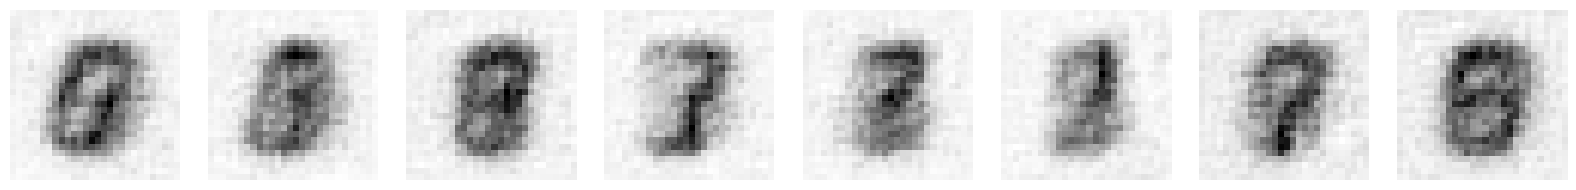

In [ ]:
# naive sampling strategy: just run the model on random noise and hope for the best
x = torch.rand(8, 1, 28, 28).to(device)
with torch.no_grad():
    pred = net(x)
    
fig, axs = plt.subplots(1, 8, figsize=(16, 2))
pred_vis = pred.detach().cpu().squeeze(1)  # (8, 28, 28)
for j, ax in enumerate(axs):
    ax.imshow(pred_vis[j], cmap="Greys")
    ax.axis("off")
plt.tight_layout()
plt.show()

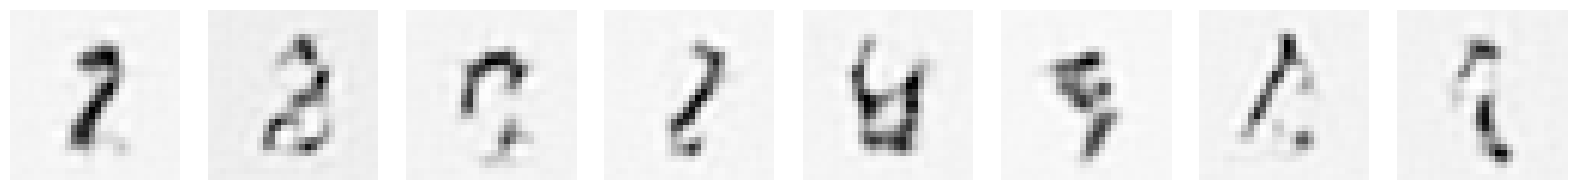

In [ ]:
#Sampling strategy: Break the process into 5 steps and move 1/5'th of the way there each time:
n_steps = 5
x = torch.rand(8, 1, 28, 28).to(device) # Start from random
images = []

for i in range(n_steps):
    with torch.no_grad(): # No need to track gradients during inference
        pred = net(x) # Predict the denoised x0
    mix_factor = 1/(n_steps - i) # How much we move towards the prediction, which is dynamically changing
    x = x*(1-mix_factor) + pred*mix_factor # Move part of the way there

fig, axs = plt.subplots(1, 8, figsize=(16, 2))
x_vis = x.detach().cpu().squeeze(1)  # (8, 28, 28)
for j, ax in enumerate(axs):
    ax.imshow(x_vis[j], cmap="Greys")
    ax.axis("off")
plt.tight_layout()
plt.show()


## MNIST UNet with time conditioning

In [ ]:

import torchvision

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

def corrupt(x, amount):
  """Corrupt the input `x` by mixing it with noise according to `amount`"""
  noise = torch.rand_like(x)
  amount = amount.view(-1, 1, 1, 1) # Sort shape so broadcasting works
  return x*(1-amount) + noise*amount


class TimeConditionedUNet(nn.Module):
    """A minimal UNet implementation."""
    def __init__(self, in_channels=1, out_channels=1):
        super().__init__()
        self.down_layers = torch.nn.ModuleList([ 
            nn.Conv2d(in_channels + 1, 32, kernel_size=5, padding=2),
            nn.Conv2d(32, 64, kernel_size=5, padding=2),
            nn.Conv2d(64, 64, kernel_size=5, padding=2),
        ])
        self.up_layers = torch.nn.ModuleList([
            nn.Conv2d(64, 64, kernel_size=5, padding=2),
            nn.Conv2d(64, 32, kernel_size=5, padding=2),
            nn.Conv2d(32, out_channels, kernel_size=5, padding=2), 
        ])
        self.act = nn.SiLU() # The activation function
        self.downscale = nn.MaxPool2d(2)
        self.upscale = nn.Upsample(scale_factor=2)

    def forward(self, x, t):
        h = []
        t_channel = t.view(-1, 1, 1, 1).expand(-1, 1, x.shape[2], x.shape[3])  # (B, 1, W, H)
        x = torch.cat([x, t_channel], dim=1)  # (B, C+1, W, H)
        for i, l in enumerate(self.down_layers):
            x = self.act(l(x)) # Through the layer and the activation function
            if i < 2: # For all but the third (final) down layer:
              h.append(x) # Storing output for skip connection
              x = self.downscale(x) # Downscale ready for the next layer
              
        for i, l in enumerate(self.up_layers):
            if i > 0: # For all except the first up layer
              x = self.upscale(x) # Upscale
              x += h.pop() # Fetching stored output (skip connection)
            x = self.act(l(x)) # Through the layer and the activation function
            
        return x

Finished epoch 0. Average loss for this epoch: 0.028121
Finished epoch 1. Average loss for this epoch: 0.021061
Finished epoch 2. Average loss for this epoch: 0.018969


(0.0, 0.1)

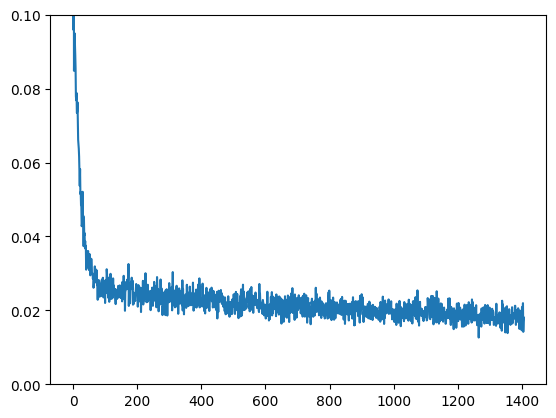

In [ ]:
# Dataloader (you can mess with batch size)
batch_size = 128
dataset = torchvision.datasets.MNIST(root="mnist/", train=True, download=True, transform=torchvision.transforms.ToTensor())
train_dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=True)

# How many runs through the data should we do?
n_epochs = 3

# Create the network
net = TimeConditionedUNet()
net.to(device)

# Our loss function
loss_fn = nn.MSELoss()

# The optimizer
opt = torch.optim.Adam(net.parameters(), lr=1e-3) 

# Keeping a record of the losses for later viewing
losses = []

# The training loop
for epoch in range(n_epochs):

    for x, y in train_dataloader:

        # Get some data and prepare the corrupted version
        x = x.to(device) # Data on the GPU
        noise_amount = torch.rand(x.shape[0]).to(device) # Pick random noise amounts
        noisy_x = corrupt(x, noise_amount) # Create our noisy x

        # Get the model prediction
        pred = net(noisy_x, noise_amount)

        # Calculate the loss
        loss = loss_fn(pred, x) # How close is the output to the true 'clean' x?

        # Backprop and update the params:
        opt.zero_grad()
        loss.backward()
        opt.step()

        # Store the loss for later
        losses.append(loss.item())

    # Print our the average of the loss values for this epoch:
    avg_loss = sum(losses[-len(train_dataloader):])/len(train_dataloader)
    print(f'Finished epoch {epoch}. Average loss for this epoch: {avg_loss:05f}')

# View the loss curve
plt.plot(losses)
plt.ylim(0, 0.1)

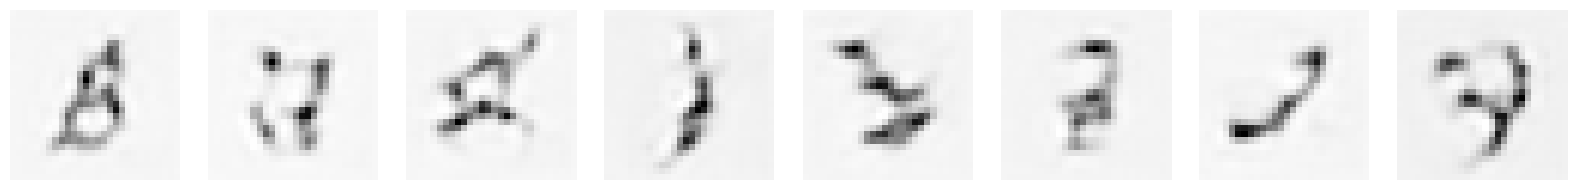

In [ ]:
#Sampling strategy: Break the process into 5 steps and move 1/5'th of the way there each time:
n_steps = 50
x = torch.rand(8, 1, 28, 28).to(device) # Start from random
images = []

for i in range(n_steps):
    t = 1 - i/n_steps
    with torch.no_grad(): # No need to track gradients during inference
        pred = net(x, torch.tensor([t], device=device).expand(8)) # Predict the denoised x0
    mix_factor = 1/(n_steps - i) # How much we move towards the prediction, which is dynamically changing
    x = x*(1-mix_factor) + pred*mix_factor # Move part of the way there

fig, axs = plt.subplots(1, 8, figsize=(16, 2))
x_vis = x.detach().cpu().squeeze(1)  # (8, 28, 28)
for j, ax in enumerate(axs):
    ax.imshow(x_vis[j], cmap="Greys")
    ax.axis("off")
plt.tight_layout()
plt.show()


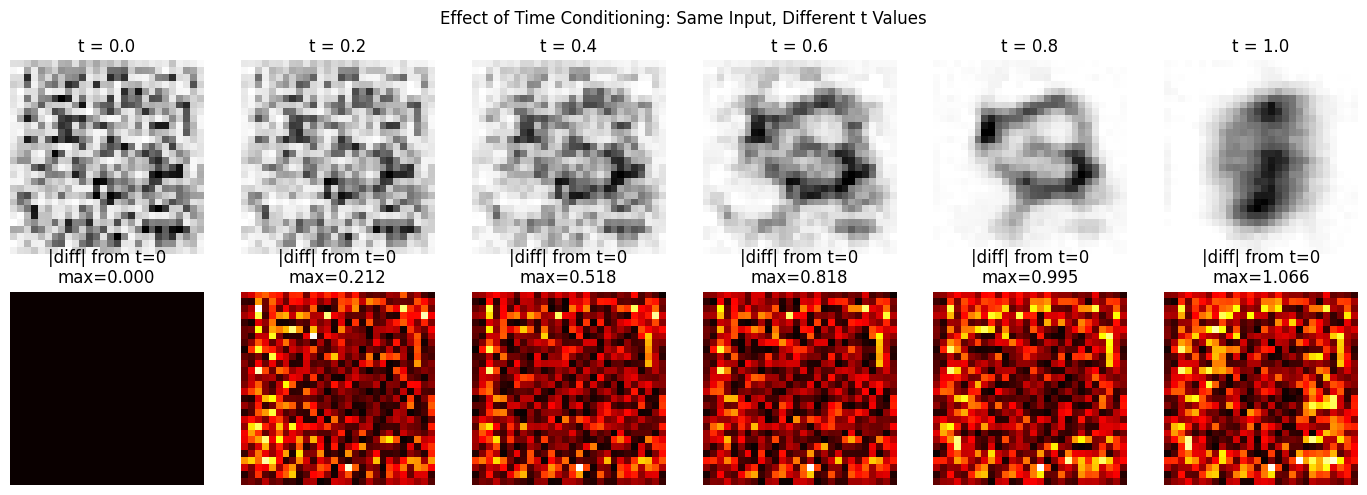


Pairwise MSE between outputs at different t values:
--------------------------------------------------
t=0.0 vs t=0.2: MSE = 0.004581
t=0.0 vs t=0.4: MSE = 0.021271
t=0.0 vs t=0.6: MSE = 0.053550
t=0.0 vs t=0.8: MSE = 0.106734
t=0.0 vs t=1.0: MSE = 0.149415
t=0.2 vs t=0.4: MSE = 0.007612
t=0.2 vs t=0.6: MSE = 0.030273
t=0.2 vs t=0.8: MSE = 0.070982
t=0.2 vs t=1.0: MSE = 0.109841
t=0.4 vs t=0.6: MSE = 0.008587
t=0.4 vs t=0.8: MSE = 0.040127
t=0.4 vs t=1.0: MSE = 0.083261
t=0.6 vs t=0.8: MSE = 0.017923
t=0.6 vs t=1.0: MSE = 0.067749
t=0.8 vs t=1.0: MSE = 0.034230

Mean pixel variance across t values: 0.026871
Max pixel variance across t values: 0.185921

✓ Time conditioning IS affecting model outputs.


In [ ]:
# Test the effect of time conditioning on model output
# Feed the SAME noisy input with DIFFERENT t values and compare outputs

# Create a fixed noisy input
torch.manual_seed(42)
fixed_input = torch.rand(1, 1, 28, 28).to(device)

# Test different t values
t_values = [0.0, 0.2, 0.4, 0.6, 0.8, 1.0]
outputs = []

with torch.no_grad():
    for t in t_values:
        t_tensor = torch.tensor([t], device=device)
        pred = net(fixed_input, t_tensor)
        outputs.append(pred.cpu().squeeze())

# Visualize outputs for each t value
fig, axs = plt.subplots(2, len(t_values), figsize=(14, 5))

# Row 1: Output images
for i, (t, out) in enumerate(zip(t_values, outputs)):
    axs[0, i].imshow(out.clip(0, 1), cmap='Greys')
    axs[0, i].set_title(f't = {t}')
    axs[0, i].axis('off')

# Row 2: Difference from t=0 output
baseline = outputs[0]
for i, (t, out) in enumerate(zip(t_values, outputs)):
    diff = (out - baseline).abs()
    axs[1, i].imshow(diff, cmap='hot')
    axs[1, i].set_title(f'|diff| from t=0\nmax={diff.max():.3f}')
    axs[1, i].axis('off')

axs[0, 0].set_ylabel('Model Output', fontsize=10)
axs[1, 0].set_ylabel('Diff from t=0', fontsize=10)
plt.suptitle('Effect of Time Conditioning: Same Input, Different t Values', fontsize=12)
plt.tight_layout()
plt.show()

# Quantitative analysis: compute pairwise differences
print("\nPairwise MSE between outputs at different t values:")
print("-" * 50)
for i, t1 in enumerate(t_values):
    for j, t2 in enumerate(t_values):
        if j > i:
            mse = ((outputs[i] - outputs[j]) ** 2).mean().item()
            print(f"t={t1:.1f} vs t={t2:.1f}: MSE = {mse:.6f}")

# Check variance across t values for each pixel
stacked = torch.stack(outputs)  # (n_t, H, W)
variance_map = stacked.var(dim=0)
print(f"\nMean pixel variance across t values: {variance_map.mean():.6f}")
print(f"Max pixel variance across t values: {variance_map.max():.6f}")

if variance_map.mean() < 1e-6:
    print("\n⚠️  WARNING: Very low variance suggests time conditioning has minimal effect!")
else:
    print("\n✓ Time conditioning IS affecting model outputs.")

## Time conditioned UNet that predicts noise

We can use the same TimeConditionedUNet model from the last cells, we just need to change what we are predicting during training

In [ ]:

import torchvision

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

def corrupt(x, amount):
  """Corrupt the input `x` by mixing it with noise according to `amount`"""
  noise = torch.randn_like(x)
  amount = amount.view(-1, 1, 1, 1) # Sort shape so broadcasting works
  return x*(1-amount) + noise*amount, noise


class TimeConditionedUNet(nn.Module):
    """A minimal UNet implementation."""
    def __init__(self, in_channels=1, out_channels=1):
        super().__init__()
        self.down_layers = torch.nn.ModuleList([ 
            nn.Conv2d(in_channels + 1, 32, kernel_size=5, padding=2),
            nn.Conv2d(32, 64, kernel_size=5, padding=2),
            nn.Conv2d(64, 64, kernel_size=5, padding=2),
        ])
        self.up_layers = torch.nn.ModuleList([
            nn.Conv2d(64, 64, kernel_size=5, padding=2),
            nn.Conv2d(64, 32, kernel_size=5, padding=2),
            nn.Conv2d(32, out_channels, kernel_size=5, padding=2), 
        ])
        self.act = nn.SiLU() # The activation function
        self.downscale = nn.MaxPool2d(2)
        self.upscale = nn.Upsample(scale_factor=2)

    def forward(self, x, t):
        h = []
        t_channel = t.view(-1, 1, 1, 1).expand(-1, 1, x.shape[2], x.shape[3])  # (B, 1, W, H)
        x = torch.cat([x, t_channel], dim=1)  # (B, C+1, W, H)
        for i, l in enumerate(self.down_layers):
            x = self.act(l(x)) # Through the layer and the activation function
            if i < 2: # For all but the third (final) down layer:
              h.append(x) # Storing output for skip connection
              x = self.downscale(x) # Downscale ready for the next layer
              
        for i, l in enumerate(self.up_layers):
            if i > 0: # For all except the first up layer
              x = self.upscale(x) # Upscale
              x += h.pop() # Fetching stored output (skip connection)
            x = self.act(l(x)) # Through the layer and the activation function
            
        return x

Finished epoch 0. Average loss for this epoch: 0.481461
Finished epoch 1. Average loss for this epoch: 0.407931
Finished epoch 2. Average loss for this epoch: 0.397206
Finished epoch 3. Average loss for this epoch: 0.390291
Finished epoch 4. Average loss for this epoch: 0.384475
Finished epoch 5. Average loss for this epoch: 0.378982
Finished epoch 6. Average loss for this epoch: 0.375203
Finished epoch 7. Average loss for this epoch: 0.372341
Finished epoch 8. Average loss for this epoch: 0.370395
Finished epoch 9. Average loss for this epoch: 0.369035


(0.0, 0.1)

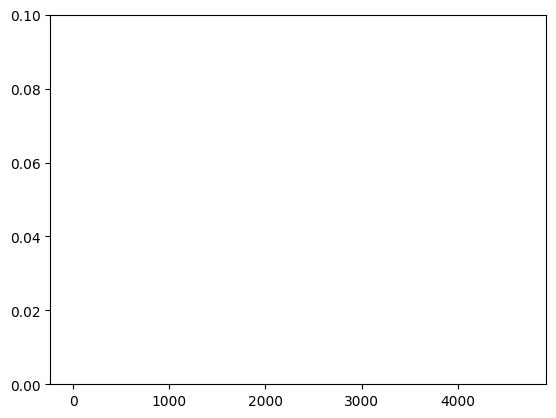

In [ ]:
# Dataloader (you can mess with batch size)
batch_size = 128
dataset = torchvision.datasets.MNIST(root="mnist/", train=True, download=True, transform=torchvision.transforms.ToTensor())
train_dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=True)

# How many runs through the data should we do?
n_epochs = 10

# Create the network
net = TimeConditionedUNet()
net.to(device)

# Our loss function
loss_fn = nn.MSELoss()

# The optimizer
opt = torch.optim.Adam(net.parameters(), lr=1e-3) 

# Keeping a record of the losses for later viewing
losses = []

# The training loop
for epoch in range(n_epochs):

    for x, y in train_dataloader:

        # Get some data and prepare the corrupted version
        x = x.to(device) # Data on the GPU
        noise_amount = torch.rand(x.shape[0]).to(device) # Pick random noise amounts
        noisy_x, noise = corrupt(x, noise_amount) # Create our noisy x

        # Get the model prediction
        pred = net(noisy_x, noise_amount)

        # Calculate the loss
        loss = loss_fn(pred, noise) # How close is the output to the true noise?

        # Backprop and update the params:
        opt.zero_grad()
        loss.backward()
        opt.step()

        # Store the loss for later
        losses.append(loss.item())

    # Print our the average of the loss values for this epoch:
    avg_loss = sum(losses[-len(train_dataloader):])/len(train_dataloader)
    print(f'Finished epoch {epoch}. Average loss for this epoch: {avg_loss:05f}')

# View the loss curve
plt.plot(losses)
plt.ylim(0, 0.1)

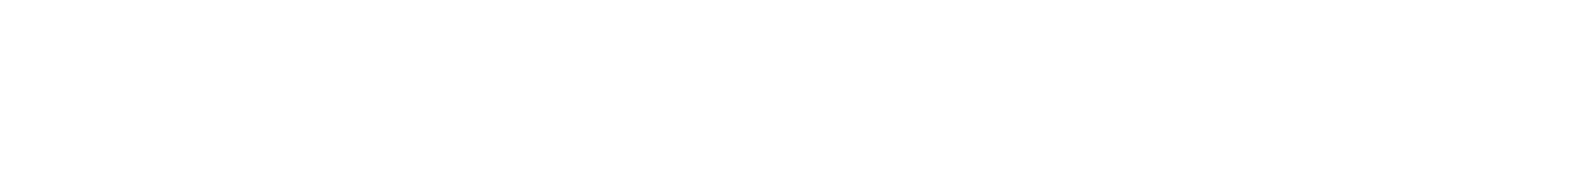

In [ ]:
# Correct sampling for noise-predicting TimeConditionedUNet
# Corruption: x_t = x_0 * (1-t) + noise * t
# Model predicts: raw noise (eps)
# To reverse: x_0 = (x_t - eps * t) / (1 - t)

n_steps = 50
sample_batchsize = 8

# Start from pure noise (t=1)
x = torch.randn(sample_batchsize, 1, 28, 28).to(device)

# Create timesteps from 1 to 0 (avoid exactly 1.0 to prevent division issues)
timesteps = torch.linspace(0.999, 0, n_steps + 1).to(device)

with torch.no_grad():
    for i in range(n_steps):
        t_curr = timesteps[i]
        t_next = timesteps[i + 1]
        
        # Predict raw noise
        eps_pred = net(x, t_curr.expand(sample_batchsize))
        
        # Estimate clean image: x_0 = (x_t - eps * t) / (1 - t)
        x0_pred = (x - eps_pred * t_curr) / (1 - t_curr)
        
        if t_next > 0:
            # Move to next noise level: x_{t_next} = x_0 * (1-t_next) + eps * t_next
            x = x0_pred * (1 - t_next) + eps_pred * t_next
        else:
            # Final step: use predicted clean image
            x = x0_pred

# Visualize results
fig, axs = plt.subplots(1, 8, figsize=(16, 2))
x_vis = x.detach().cpu().squeeze(1)
for j, ax in enumerate(axs):
    ax.imshow(x_vis[j].clip(0, 1), cmap="Greys")
    ax.axis("off")
plt.tight_layout()
plt.show()